In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
import wandb


In [24]:
BATCH_SIZE = 64
NUM_CLASSES = 7
LEARNING_RATE = 0.001
EPOCHS_NUM = 50

wandb.init(
    project="classification-model-comparison",
    config={
        "batch_size": BATCH_SIZE,
        "num_classes": NUM_CLASSES,
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCHS_NUM,
        "model":"efficientnet_b0",
    }
)

device = torch.device('cpu')

In [25]:
augmentation_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(size=224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])



In [26]:
# 1. Update augmentation transforms with more medical image-specific augmentations
device = torch.device('cpu')
# 1. Define separate transforms for train and test
# 1. Покращена аугментація для тренувального набору
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])


# Тестові трансформації також оновлюємо для відповідності
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# 3. Створюємо два окремих датасети з різними трансформаціями
train_dataset_full = ImageFolder(
    root='C:/Diploma/classification_dataset',
    transform=train_transforms  # Застосовуємо train_transforms
)

test_dataset_full = ImageFolder(
    root='C:/Diploma/classification_dataset',
    transform=test_transforms  # Застосовуємо test_transforms
)

# 4. Отримуємо labels для стратифікації
labels = [label for _, label in train_dataset_full]

# 5. Створюємо індекси для розділення
train_indices, test_indices = train_test_split(
    range(len(train_dataset_full)), 
    test_size=0.15, 
    stratify=labels, 
    random_state=42
)

# 6. Створюємо підмножини
train_dataset = Subset(train_dataset_full, train_indices)
test_dataset = Subset(test_dataset_full, test_indices)

# 7. Створюємо завантажувачі даних
train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
# test_dataset.dataset.transform = test_transforms

# 9. Print dataset information
print(f"Classes: {train_dataset_full.classes}")
print(f"Total samples: {len(train_dataset_full)}")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")


Classes: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k']
Total samples: 14317
Training samples: 12169
Testing samples: 2148



Displaying first 10 samples from Training Dataset:


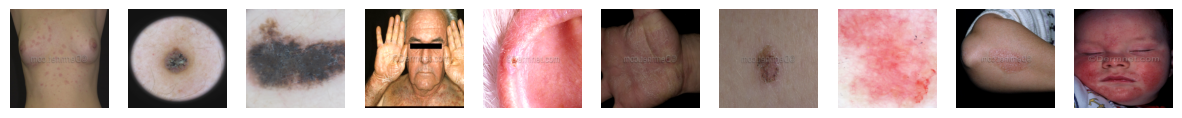

Class Labels Mapping: {5: '7. Psoriasis pictures Lichen Planus and related diseases - 2k', 4: '6. Benign Keratosis-like Lesions (BKL) 2624', 6: '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', 3: '4. Basal Cell Carcinoma (BCC) 3323', 2: '3. Atopic Dermatitis - 1.25k'}

Displaying first 10 samples from Testing Dataset:


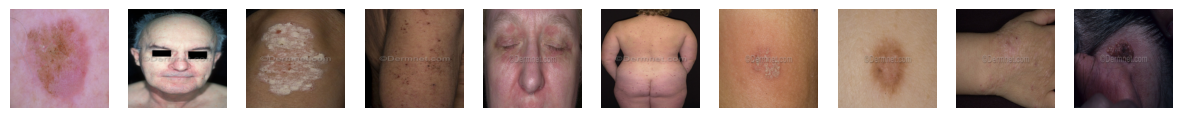

Class Labels Mapping: {5: '7. Psoriasis pictures Lichen Planus and related diseases - 2k', 4: '6. Benign Keratosis-like Lesions (BKL) 2624', 6: '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', 3: '4. Basal Cell Carcinoma (BCC) 3323', 2: '3. Atopic Dermatitis - 1.25k', 1: '10. Warts Molluscum and other Viral Infections - 2103'}


In [27]:
import matplotlib.pyplot as plt

print("\nDisplaying first 10 samples from Training Dataset:")
plt.figure(figsize=(15, 5))

class_labels = {}

for i in range(10):
    image, label = train_dataset[i]  
    class_labels[label] = train_dataset.dataset.classes[label]

    plt.subplot(1, 10, i + 1)
    plt.imshow(image.permute(1, 2, 0).clamp(0, 1).numpy())  # Нормалізація в діапазон [0,1]
    plt.axis('off')

plt.show()
print("Class Labels Mapping:", class_labels)

print("\nDisplaying first 10 samples from Testing Dataset:")
plt.figure(figsize=(15, 5))

for i in range(10):
    image, label = test_dataset[i]
    class_labels[label] = test_dataset.dataset.classes[label]

    plt.subplot(1, 10, i + 1)
    plt.imshow(image.permute(1, 2, 0).clamp(0, 1).numpy())  # Нормалізація в діапазон [0,1]
    plt.axis('off') 

plt.show()
print("Class Labels Mapping:", class_labels)


In [28]:
# Load Pretrained EfficientNet Model
model = models.efficientnet_b0(pretrained=True)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASSES)
)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

c:\Diploma\Diploma\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Diploma\Diploma\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [29]:
from utils import evaluate, train


def train_model(model, criterion, optimizer, num_epochs):
    for epoch in range(num_epochs):
        train_loss, train_acc, train_prec, train_rec, train_f1 = train(model, criterion, optimizer,device,train_loader)
        eval_acc, eval_prec, eval_rec, eval_f1 = evaluate(model,device,test_loader)

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Prec: {train_prec:.4f}, Rec: {train_rec:.4f},F1: {train_f1:.4f}")
        wandb.log({
                "Training/Loss": train_loss,
                "Training/Accuracy": train_acc,
                "Training/Precision": train_prec,
                "Training/Recall": train_rec,
                "Training/F1_Score": train_f1
            })

        print(f"Eval  - Acc: {eval_acc:.4f}, Prec: {eval_prec:.4f}, Rec: {eval_rec:.4f}, F1: {eval_f1:.4f}")
        wandb.log({
        "Evaluation/Accuracy": eval_acc,
        "Evaluation/Precision": eval_prec,
        "Evaluation/Recall": eval_rec,
        "Evaluation/F1_Score": eval_f1
    })

    return model

model = train_model(model, criterion, optimizer, EPOCHS_NUM)


Epoch [1/50]
Train - Loss: 0.9107, Acc: 0.6408, Prec: 0.6388, Rec: 0.6408,F1: 0.6395
Eval  - Acc: 0.7128, Prec: 0.7191, Rec: 0.7128, F1: 0.7131
Epoch [2/50]
Train - Loss: 0.6719, Acc: 0.7437, Prec: 0.7429, Rec: 0.7437,F1: 0.7431
Eval  - Acc: 0.7374, Prec: 0.7444, Rec: 0.7374, F1: 0.7381
Epoch [3/50]
Train - Loss: 0.5628, Acc: 0.7885, Prec: 0.7880, Rec: 0.7885,F1: 0.7882
Eval  - Acc: 0.7733, Prec: 0.7954, Rec: 0.7733, F1: 0.7771
Epoch [4/50]
Train - Loss: 0.4611, Acc: 0.8286, Prec: 0.8289, Rec: 0.8286,F1: 0.8286
Eval  - Acc: 0.7551, Prec: 0.7576, Rec: 0.7551, F1: 0.7551
Epoch [5/50]
Train - Loss: 0.3909, Acc: 0.8544, Prec: 0.8546, Rec: 0.8544,F1: 0.8544
Eval  - Acc: 0.7789, Prec: 0.7777, Rec: 0.7789, F1: 0.7759
Epoch [6/50]
Train - Loss: 0.3450, Acc: 0.8743, Prec: 0.8744, Rec: 0.8743,F1: 0.8743
Eval  - Acc: 0.7723, Prec: 0.7912, Rec: 0.7723, F1: 0.7719
Epoch [7/50]
Train - Loss: 0.2987, Acc: 0.8894, Prec: 0.8896, Rec: 0.8894,F1: 0.8895
Eval  - Acc: 0.7896, Prec: 0.8021, Rec: 0.7896, F1:

In [30]:
model.eval()
correct = 0
total = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f'Final Accuracy on {len(test_dataset)} test images: {accuracy:.2f} %')

wandb.log({"final_test_accuracy": accuracy})


Final Accuracy on 2148 test images: 81.47 %


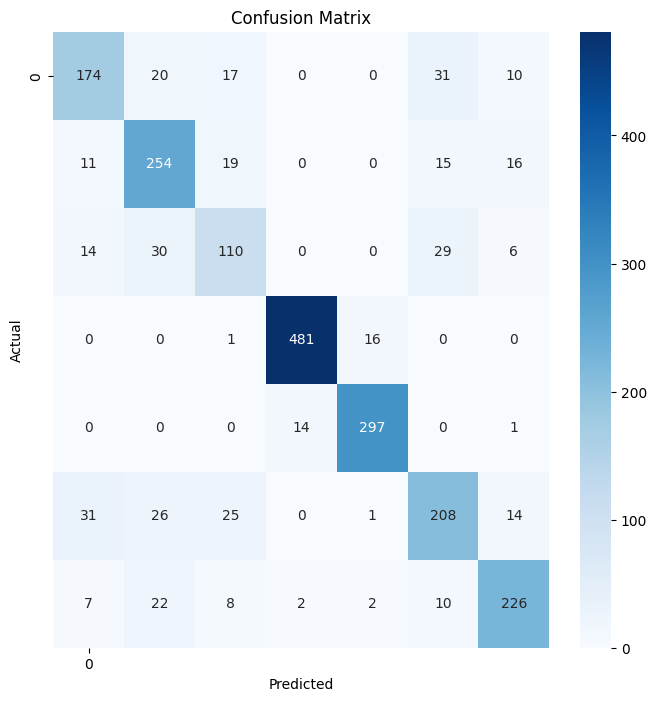

In [31]:
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix

model.eval()
correct, total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=NUM_CLASSES, yticklabels=NUM_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Логування у wandb (якщо потрібно)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=NUM_CLASSES, yticklabels=NUM_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
wandb.log({"confusion_matrix": wandb.Image(fig)})
plt.close()

In [32]:
torch.save(model.state_dict(), "../files/efficientnet_skin_disease_model.pth")
print("Model training complete and saved.")

Model training complete and saved.


In [33]:
wandb.finish()

Evaluation/Accuracy,▂▂▂▃▁▁▃▂▄▂▃▄▄▃▃▃▃▃▄▃▆▇▇█▇▇▇▇▇▇██████████
Evaluation/F1_Score,▂▃▃▂▂▂▃▄▃▃▃▃▁▃▃▃▂▆▇▇▇▇█▇▇█▇▇█▇██████████
Evaluation/Precision,▁▁▃▂▂▃▁▂▂▃▃▃▃▂▃▂▃▃▃▂▇▆▇▇▇▇▇▇█▇█████▇██▇█
Evaluation/Recall,▂▃▁▂▃▄▃▂▃▃▃▂▃▁▃▃▂▆▇▇▇▇▇▇▇█▇██▇█████▇█▇██
Training/Accuracy,▁▃▅▅▆▇▇▇▇▇▇▇▇▇██████▁▅▅▆▆▇▇▇▇███████████
Training/F1_Score,▁▄▅▆▆▇▇▇▇████████▁▅▆▇▇▇▇▇███████████████
Training/Loss,█▇▆▄▄▃▂▂▂▂▂▂▂▁▂▁▁▁▁▇▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
Training/Precision,▃▄▅▅▆▇▇███████████▁▄▅▆▆▆▇█▇█████████████
Training/Recall,▁▄▅▅▆▆▇▇▇▇█████▁▃▄▄▅▇▇▇▇▇▇▇▇████████████
final_test_accuracy,▁
Evaluation/Accuracy,0.81471
